# Mission 2 — Préparation et pipeline sans fuite de données

**Point noté le plus strictement de tout le projet.** Le `train_test_split`
stratifié doit intervenir **avant** toute transformation apprise. Toutes ces
transformations vivent dans un `Pipeline` / `ColumnTransformer` scikit-learn,
ajusté sur le train seul.

**Rappel du cadrage (M0)** — métrique principale : coût métier moyen par client,
C_FN = 350 €, C_FP = 40 €, seuil théorique ≈ 0,1026. Cible : ≤ 65 €/client.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)

from src.features import (COUT_FN, COUT_FP, RANDOM_STATE, SEUIL_THEORIQUE,
                          charger_donnees, construire_pipeline, cout_metier)

DATA = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
print(f"Seuil théorique (M0) : {SEUIL_THEORIQUE:.4f}")

Seuil théorique (M0) : 0.1026


## 1. Le split, avant tout le reste

### Pourquoi ce découpage doit-il précéder imputation, encodage et scaling ?

Parce que ces trois opérations **apprennent des statistiques sur les données**
qu'on leur donne :

| Transformation | Statistique apprise | Ce qui fuirait |
|---|---|---|
| `SimpleImputer(median)` | la médiane de la colonne | la distribution du test |
| `StandardScaler` | moyenne et écart-type | idem |
| `OneHotEncoder` | la liste des modalités | l'existence de modalités propres au test |

Ajuster l'une d'elles sur l'ensemble complet ferait entrer de l'information du
test dans le train. Le score de test cesserait alors d'estimer la performance
sur des données jamais vues : il serait **optimiste**, et l'estimation servant à
décider du déploiement deviendrait fausse.

La stratification, elle, garantit que les deux ensembles conservent le taux de
churn de 26,54 % — sans quoi les deux scores ne seraient pas comparables.

In [2]:
X, y = charger_donnees(DATA)
print(f"X : {X.shape}  |  taux de churn global : {y.mean():.4f}")
print(f"Colonnes exclues : customerID (identifiant), gender (MI nulle, attribut protégé)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"\nTrain : {X_train.shape}  churn = {y_train.mean():.4f}")
print(f"Test  : {X_test.shape}   churn = {y_test.mean():.4f}")
print("\nÀ partir d'ici, X_test et y_test ne sont plus touchés jusqu'à la Mission 4.")

X : (7043, 18)  |  taux de churn global : 0.2654
Colonnes exclues : customerID (identifiant), gender (MI nulle, attribut protégé)

Train : (5634, 18)  churn = 0.2654
Test  : (1409, 18)   churn = 0.2654

À partir d'ici, X_test et y_test ne sont plus touchés jusqu'à la Mission 4.


## 2. Le pipeline

Le `ColumnTransformer` est construit dans `src/features.py`. Trois branches :

- **`TotalCharges`** — imputation par la **constante 0**, puis standardisation.
- **Autres numériques** — imputation médiane, puis standardisation.
- **Catégorielles** — imputation par le mode, puis one-hot avec
  `handle_unknown="ignore"` (une modalité inconnue en production produit un
  vecteur nul plutôt qu'une erreur).

### Écart assumé avec l'énoncé sur `TotalCharges`

L'énoncé prescrit une imputation médiane pour le sous-pipeline numérique. Le
diagnostic de la Mission 1 montre que ce choix serait **sémantiquement faux ici** :
les 11 valeurs absentes correspondent toutes à des clients dont `tenure == 0`,
qui n'ont jamais été facturés. Leur total vaut 0, pas la médiane du parc (≈ 1 400 €).

L'imputation médiane est conservée pour toutes les autres colonnes numériques,
comme filet de sécurité en production. La constante 0 est une constante, donc
sans statistique apprise et sans risque de fuite.

### Où, exactement, les statistiques sont-elles apprises ?

Uniquement dans `Pipeline.fit()`, appelé sur `X_train`. Chaque appel ultérieur à
`transform()` — validation croisée, test, requête API — **réutilise** les valeurs
mémorisées au `fit`, sans jamais les recalculer. C'est cette mécanique, et non
une discipline de programmation, qui rend la fuite structurellement impossible.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "cout": make_scorer(cout_metier, response_method="predict_proba",
                        greater_is_better=False),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "recall": make_scorer(
        lambda yt, p: recall_score(yt, (p >= SEUIL_THEORIQUE).astype(int)),
        response_method="predict_proba"),
}

def evaluer(nom, **features):
    """Validation croisée d'une configuration de features."""
    pipe = construire_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        X_train, **features)
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "configuration": nom,
        "cout_moyen": -r["test_cout"].mean(),
        "ecart_type": r["test_cout"].std(),
        "roc_auc": r["test_roc_auc"].mean(),
        "auc_pr": r["test_average_precision"].mean(),
        "rappel": r["test_recall"].mean(),
        "_plis": -r["test_cout"],
    }

pipe_baseline = construire_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), X_train)
pipe_baseline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('enrichissement', ...), ('pretraitement', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function enr...t 0x146889170>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{}
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_ou

## 3. Baseline

Deux références à distinguer :

- **La baseline naïve** — prédire « personne ne churne ». Elle ne coûte rien à
  produire et sert de plancher absolu.
- **La baseline modèle** — la régression logistique dans le pipeline, sans aucune
  feature créée. C'est la valeur que le feature engineering devra battre.

In [4]:
cout_naif = y_train.mean() * COUT_FN
print(f"Baseline naïve (tout non-churn) : {cout_naif:.2f} €/client")
print(f"  → tous les churners sont manqués : {int(y_train.sum())} FN, 0 FP\n")

base = evaluer("baseline (aucune feature créée)")
print(f"Baseline modèle : {base['cout_moyen']:.2f} ± {base['ecart_type']:.2f} €/client")
print(f"  ROC-AUC = {base['roc_auc']:.4f} | AUC-PR = {base['auc_pr']:.4f} | rappel = {base['rappel']:.4f}")
print(f"\nRéduction du coût : {(1 - base['cout_moyen'] / cout_naif):.1%}")
print(f"Cible M0 (≤ 65 €/client) : {'ATTEINTE' if base['cout_moyen'] <= 65 else 'NON ATTEINTE'}")

Baseline naïve (tout non-churn) : 92.87 €/client
  → tous les churners sont manqués : 1495 FN, 0 FP

Baseline modèle : 20.60 ± 0.88 €/client
  ROC-AUC = 0.8461 | AUC-PR = 0.6608 | rappel = 0.9385

Réduction du coût : 77.8%
Cible M0 (≤ 65 €/client) : ATTEINTE


**La cible du cadrage est déjà dépassée par la baseline.** 20,60 € contre
92,87 € pour la naïve, soit −77,8 %, très en deçà des 65 € visés.

Ce n'est pas le signe d'un problème facile : c'est le signe que **le seuil de
décision fait le gros du travail**. Vérifions-le, car cette observation est le
résultat le plus important de cette mission.

In [5]:
proba_cv = cross_val_predict(pipe_baseline, X_train, y_train, cv=cv,
                             method="predict_proba")[:, 1]

lignes = []
for seuil in [0.5, SEUIL_THEORIQUE]:
    pred = (proba_cv >= seuil).astype(int)
    vp = int(((y_train == 1) & (pred == 1)).sum())
    fn = int(((y_train == 1) & (pred == 0)).sum())
    fp = int(((y_train == 0) & (pred == 1)).sum())
    lignes.append({
        "seuil": round(seuil, 4), "VP": vp, "FN": fn, "FP": fp,
        "clients_cibles": f"{pred.mean():.1%}",
        "rappel": round(vp / (vp + fn), 3),
        "cout_€/client": round((COUT_FN * fn + COUT_FP * fp) / len(y_train), 2),
    })
pd.DataFrame(lignes)

,seuil,VP,FN,FP,clients_cibles,rappel,cout_€/client
0,0.5000,816,679,431,22.1%,0.546,45.24
1,0.1026,1403,92,2097,62.1%,0.938,20.60


### L'effet du seuil écrase tout le reste

| Seuil | Coût | Rappel | Clients ciblés |
|---|---|---|---|
| 0,50 (défaut) | 45,24 € | 0,546 | 22,1 % |
| 0,1026 (théorique) | **20,60 €** | **0,938** | 62,1 % |

Le même modèle, avec les mêmes probabilités, coûte **deux fois moins cher** en
changeant simplement le seuil. Aucun raffinement de modélisation dans la suite du
projet ne produira un gain de cette ampleur. C'est la démonstration empirique de
ce que le cadrage prédisait : optimiser l'accuracy à 0,5 aurait conduit à un
système deux fois plus coûteux.

**Une réserve opérationnelle, à porter au rapport.** Cibler 62 % du parc n'est
plus une « liste de priorité » : c'est une campagne de masse. La matrice de
coûts de la Mission 0, prise au pied de la lettre, pousse mécaniquement vers ce
régime, parce qu'un FN coûte 9 FP. En pratique le marketing dispose d'un budget
fini. La Mission 4 devra donc examiner le seuil sous **contrainte de capacité**
(ex. « ne cibler que les 20 % les plus à risque ») en complément du seuil
purement économique.

## 4. Feature engineering

Trois features issues des hypothèses validées en Mission 1 :

| Feature | Hypothèse d'origine | Intention |
|---|---|---|
| `tenure_bucket` | H2 — risque concentré et non linéaire | donner au modèle linéaire la forme de la courbe |
| `nb_services` | H5 — six colonnes redondantes | résumer en une variable ordonnable |
| `price_drift` | H3 — le prix perçu alimente le départ | rapport facture actuelle / facture moyenne historique |

Sur `price_drift` : le ratio brut *charges / ancienneté* aurait été inutile, car
`TotalCharges / tenure ≈ MonthlyCharges` — on aurait recréé une colonne existante.
Le rapport entre facture **actuelle** et facture **moyenne historique** apporte au
contraire une information neuve : il détecte une hausse tarifaire récente.

L'énoncé impose de vérifier que chaque feature améliore réellement le score, et
de la supprimer sinon. On les teste donc **une par une, sur les mêmes plis**.

In [6]:
resultats = [base]
for nom, kw in [("+ tenure_bucket", dict(tenure_bucket=True)),
                ("+ nb_services", dict(nb_services=True)),
                ("+ price_drift", dict(price_drift=True)),
                ("les 3 ensemble", dict(tenure_bucket=True, nb_services=True,
                                        price_drift=True))]:
    resultats.append(evaluer(nom, **kw))

tab = pd.DataFrame(resultats).drop(columns="_plis")
tab["gain_€"] = tab["cout_moyen"].iloc[0] - tab["cout_moyen"]
tab.round(4)

,configuration,cout_moyen,ecart_type,roc_auc,auc_pr,rappel,gain_€
0,baseline (aucune feature créée),20.6034,0.8820,0.8461,0.6608,0.9385,0.0000
1,+ tenure_bucket,20.2270,0.8210,0.8480,0.6646,0.9385,0.3764
2,+ nb_services,20.5750,0.8785,0.8464,0.6615,0.9385,0.0284
3,+ price_drift,20.5892,0.8849,0.8459,0.6602,0.9385,0.0142
4,les 3 ensemble,20.3654,0.9020,0.8476,0.6632,0.9371,0.2380


### Le gain est-il réel, ou du bruit ?

Un écart de 0,38 € face à un écart-type inter-plis de 0,88 € ne prouve rien.
Comme les cinq plis sont identiques d'une configuration à l'autre, la comparaison
peut être **appariée** — c'est le test de Wilcoxon, que la Mission 3 utilisera
aussi pour départager les modèles.

In [7]:
plis_base = base["_plis"]
comparaison = []
for r in resultats[1:]:
    diff = plis_base - r["_plis"]
    stat, p = wilcoxon(plis_base, r["_plis"])
    comparaison.append({
        "configuration": r["configuration"],
        "gain_moyen_€": round(diff.mean(), 3),
        "plis_ameliores": f"{int((diff > 0).sum())}/5",
        "p_value": round(p, 3),
        "significatif_5%": "non" if p >= 0.05 else "oui",
    })
pd.DataFrame(comparaison)

,configuration,gain_moyen_€,plis_ameliores,p_value,significatif_5%
0,+ tenure_bucket,0.376,3/5,0.312,non
1,+ nb_services,0.028,2/5,0.500,non
2,+ price_drift,0.014,1/5,1.000,non
3,les 3 ensemble,0.238,3/5,0.625,non


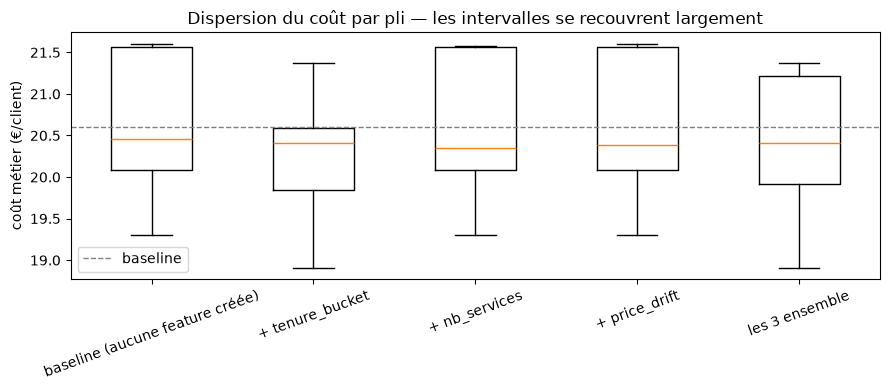

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
donnees = [r["_plis"] for r in resultats]
ax.boxplot(donnees, tick_labels=[r["configuration"] for r in resultats])
ax.axhline(base["cout_moyen"], color="grey", ls="--", lw=1, label="baseline")
ax.set_ylabel("coût métier (€/client)")
ax.set_title("Dispersion du coût par pli — les intervalles se recouvrent largement")
ax.tick_params(axis="x", rotation=20); ax.legend()
plt.tight_layout(); plt.show()

### Verdict : le rasoir d'Occam s'applique

**Aucune des trois features ne produit un gain statistiquement significatif.**
Les p-valeurs valent 0,312 / 0,500 / 1,000 — toutes très au-dessus de 0,05. Les
boîtes se recouvrent largement.

Trois observations méritent d'être versées au rapport :

1. **`tenure_bucket` est la moins mauvaise** : +0,38 €, 3 plis sur 5 améliorés,
   et c'est la seule à améliorer simultanément le coût, le ROC-AUC (0,8480 contre
   0,8461) et l'AUC-PR, tout en **réduisant la variance** (0,82 contre 0,88).
2. **Les trois ensemble font moins bien que `tenure_bucket` seule** (+0,24 contre
   +0,38). Empiler des features corrélées dégrade : c'est exactement le phénomène
   que le rasoir d'Occam cherche à éviter.
3. **`price_drift` n'améliore qu'un pli sur cinq** (p = 1,000). L'idée était
   défendable, la mesure la réfute : elle est écartée.

**Décision retenue.** On conserve **`tenure_bucket` seule**, sur un faisceau
d'indices convergents (trois métriques améliorées, variance réduite) tout en
reconnaissant que le gain n'est pas significatif à 5 %. `nb_services` et
`price_drift` sont supprimées.

Cette décision sera réexaminée en Mission 3 : un modèle à base d'arbres découpe
`tenure` lui-même, donc `tenure_bucket` devrait lui être **inutile**. Si c'est le
cas, ce sera une illustration nette du fait qu'une feature n'a pas de valeur en
soi, mais seulement relativement à la famille de modèles qui la consomme.

## 5. Tableau de synthèse — livrable M2

In [9]:
synthese = pd.DataFrame([
    {"étape": "Baseline naïve (classe majoritaire)", "coût €/client": round(cout_naif, 2),
     "ROC-AUC": None, "rappel": 0.0},
    {"étape": "Pipeline + régression logistique", "coût €/client": round(base["cout_moyen"], 2),
     "ROC-AUC": round(base["roc_auc"], 4), "rappel": round(base["rappel"], 4)},
    {"étape": "Pipeline + tenure_bucket (retenu)",
     "coût €/client": round(resultats[1]["cout_moyen"], 2),
     "ROC-AUC": round(resultats[1]["roc_auc"], 4), "rappel": round(resultats[1]["rappel"], 4)},
])
synthese["gain vs naïve"] = (1 - synthese["coût €/client"] / cout_naif).map("{:.1%}".format)
synthese

,étape,coût €/client,ROC-AUC,rappel,gain vs naïve
0,Baseline naïve (classe majoritaire),92.87,NaN,0.0000,0.0%
1,Pipeline + régression logistique,20.60,0.8461,0.9385,77.8%
2,Pipeline + tenure_bucket (retenu),20.23,0.8480,0.9385,78.2%


### Ce qui est acquis à l'issue de la Mission 2

- Un **pipeline unique et reproductible**, où toute statistique apprise l'est sur
  le train seul — la fuite est rendue structurellement impossible.
- Une **baseline à 20,60 €/client**, contre 92,87 € pour la naïve (−77,8 %), déjà
  sous la cible de 65 €/client fixée en M0.
- Un **gain de feature engineering chiffré et honnêtement qualifié** : non
  significatif, une seule feature conservée sur trois.
- Le constat que **le seuil de décision pèse davantage que la modélisation**
  (45,24 € contre 20,60 € pour le même modèle), ce que la Mission 4 devra
  exploiter.

Le jeu de test n'a pas été touché.